# **MLProcess - Smoke Detector**
---
**4 - Modeling, Tuning, and Evaluation**

In [1]:
# Import the required libraries.
import copy
import json
import hashlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Model related classes.
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.linear_model import LogisticRegression as LGR
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.ensemble import (
    BaggingClassifier as BGC,
    RandomForestClassifier as RFC,
    AdaBoostClassifier as ABC,
    GradientBoostingClassifier as GBC
)

from sklearn.metrics import (
    recall_score,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import (
    RandomizedSearchCV,
    GridSearchCV
)

import src.utils as utils

import warnings
warnings.filterwarnings("ignore")

## **1 - Configuration File**
---

In [2]:
# Load the conifguration file.
config = utils.load_config()
utils.print_debug("Config file loaded...")

2026-03-07 03:07:37.187468 Config file loaded...


In [3]:
# Check the configuration file.
config

{'columns_datetime': ['utc'],
 'columns_float': ['temperature',
  'humidity_pct',
  'pressure',
  'pm10',
  'pm25',
  'nc05',
  'nc10',
  'nc25'],
 'columns_int': ['tvoc', 'co2', 'raw_h2', 'raw_ethanol', 'fire_alarm'],
 'features': ['temperature',
  'humidity_pct',
  'pressure',
  'pm10',
  'tvoc',
  'co2',
  'raw_h2',
  'raw_ethanol'],
 'label': 'fire_alarm',
 'path_clean_test': ['data/processed/X_test_clean.pkl',
  'data/processed/y_test_clean.pkl'],
 'path_clean_train': ['data/processed/X_train_clean.pkl',
  'data/processed/y_train_clean.pkl'],
 'path_clean_valid': ['data/processed/X_valid_clean.pkl',
  'data/processed/y_valid_clean.pkl'],
 'path_data_raw': 'data/raw/smoke_detection_iot.csv',
 'path_data_test': ['data/interim/X_test.pkl', 'data/interim/y_test.pkl'],
 'path_data_train': ['data/interim/X_train.pkl', 'data/interim/y_train.pkl'],
 'path_data_valid': ['data/interim/X_valid.pkl', 'data/interim/y_valid.pkl'],
 'path_data_validated': 'data/interim/validated_data.pkl',
 'pat

## **2 - Load Data**
---

In [4]:
# Function to load preprocessed data.
def load_data(config, data_conf):
    """
    Load the preprocessed data.

    Parameters:
    ----------
    config : dict
        The loaded configuration file.

    data_conf : str
        The data configuration type.
        The value must one of these value: ['train', 'valid', 'test']
    """

    # Ensure the data_conf is valid.
    list_data_conf = ["train", "valid", "test"]

    if data_conf not in list_data_conf:
        raise RuntimeError(f"The data configuration {data_conf} is invalid.")
    else:
        data_conf = str(data_conf)
        path = f"path_clean_{data_conf}"

        X = utils.deserialize_data(config[path][0])
        y = utils.deserialize_data(config[path][1])

        return X, y

In [5]:
# Load the data.
X_train, y_train = load_data(config, "train")
X_valid, y_valid = load_data(config, "valid")
X_test, y_test = load_data(config, "test")

Data deserialized from data/processed/X_train_clean.pkl
Data deserialized from data/processed/y_train_clean.pkl
Data deserialized from data/processed/X_valid_clean.pkl
Data deserialized from data/processed/y_valid_clean.pkl
Data deserialized from data/processed/X_test_clean.pkl
Data deserialized from data/processed/y_test_clean.pkl


In [6]:
# Sanity check the train set.
data_train = pd.concat(
    [X_train, y_train],
    axis = 1
)

data_train

,temperature,humidity_pct,pressure,pm10,tvoc,co2,raw_h2,raw_ethanol,fire_alarm
0,1.002946,-1.528159,-0.557151,0.976230,0.859642,4.103077,-1.240708,-0.874186,1
1,0.926177,-0.133637,-0.983044,0.488360,1.109081,-0.445069,-0.379715,-0.983040,1
2,0.772640,0.681833,-0.896034,0.330520,0.844969,-0.331365,-0.919660,-0.842170,1
3,0.546797,-0.740100,1.134973,1.564542,-1.234917,-0.445069,1.721690,1.655083,1
4,-1.269406,-1.678918,1.155581,0.732295,-1.009321,-0.445069,1.378752,1.120415,1
...,...,...,...,...,...,...,...,...,...
50459,0.215740,-0.428034,0.987274,-0.950103,-1.292002,-0.445069,0.862505,1.086416,0
50460,0.320546,-0.840402,1.012357,-0.472563,-1.229266,-0.445069,1.295663,1.335747,0
50461,0.115864,-0.183506,1.000444,-0.988582,-1.139414,-0.445069,0.618622,0.828729,0
50462,0.406933,-1.613489,1.168505,-0.979571,-0.954600,-0.445069,0.872194,0.895208,0


## **3 - Training Log**
---

In [7]:
# Function to create training log.
def create_training_log():
    """Return a dictionary representing the training log structure."""
    logger = {
        "model_name": [],
        "model_id": [],
        "training_time": [],
        "training_date": [],
        "train_score": [],
        "cv_score": []
    }

    return logger

In [8]:
# Function to update training log.
def update_training_log(current_log, path_log):
    """
    Update the training log.

    Parameters:
    ----------
    current_log : dict
        The training log current state.

    path_log : str
        The directory of training log.

    Returns:
    -------
    last_log : dict
        The updated training log.
    """

    # Ensure the current log immutable.
    current_log = copy.deepcopy(current_log)

    # Open the training log file.
    try:
        with open(path_log, 'r') as file:
            last_log = json.load(file)
        file.close()
        
    # If the training log does not exists.
    except FileNotFoundError as err:
        # Create the new training log.
        with open(path_log, 'w') as file:
            file.write("[]")
        file.close()

        # Reload the new training log.
        with open(path_log, 'r') as file:
            last_log = json.load(file)
        file.close()

    # Add the current log to previous log.
    last_log.append(current_log)

    # Rewrite the training log with the updated one.
    with open(path_log, 'w') as file:
        json.dump(last_log, file)
        file.close()

    return last_log

## **4 - Model Training**
---

In [9]:
# Function to create model object.
def create_model_object():
    """Return a list of model to be fitted."""

    # Create model object.
    knn = KNN()
    lgr = LGR()
    dtc = DTC()
    bgc = BGC()
    rfc = RFC()
    abc = ABC()
    gbc = GBC()

    # Create list of model.
    list_of_model = [
        {"model_name": knn.__class__.__name__, "model_object": knn, "model_id": ""},
        {"model_name": lgr.__class__.__name__, "model_object": lgr, "model_id": ""},
        {"model_name": dtc.__class__.__name__, "model_object": dtc, "model_id": ""},
        {"model_name": bgc.__class__.__name__, "model_object": bgc, "model_id": ""},
        {"model_name": rfc.__class__.__name__, "model_object": rfc, "model_id": ""},
        {"model_name": abc.__class__.__name__, "model_object": abc, "model_id": ""},
        {"model_name": gbc.__class__.__name__, "model_object": gbc, "model_id": ""}
    ]

    return list_of_model

In [10]:
# Function to create hyperparameter space.
def create_param_space():
    """Return a dict of model hyperparameter."""

    # Define each model hyprerparameter space.
    knn_params = {
        "n_neighbors": [2, 3, 4, 5, 6, 10, 15],
        "weights": ["uniform", "distance"],
        "p": [1, 2]
    }

    lgr_params = {
        "C": [0.01, 0.1, 1.0, 10.0]
    }

    # Hyperparameter for DTC, RFC, and GBC.
    DEPTH = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

    # Hyperparameter for BGC, RFC, ABC, and GBC.
    B = [10, 50, 100, 150, 200, 250, 300, 350, 400]
    
    # Hyperparameter for ABC and GBC.
    LR = [0.001, 0.01, 0.05, 0.1, 1]

    dist_params = {
        "KNeighborsClassifier": knn_params,
        "LogisticRegression": lgr_params,
        "DecisionTreeClassifier": {
            "max_depth": DEPTH
        },
        "BaggingClassifier": {
            "n_estimators": B
        },
        "RandomForestClassifier": {
            "n_estimators": B,
            "max_depth": DEPTH
        },
        "AdaBoostClassifier": {
            "n_estimators": B,
            "learning_rate": LR
        },
        "GradientBoostingClassifier": {
            "n_estimators": B,
            "learning_rate": LR,
            "max_depth": DEPTH
        }
    }

    return dist_params

### **4.1. Define Metrics**

- Considering class `1` (fire detected) is the positive class.

- False Positive:
    - Predicted: fire detected
    - Actual: no fire
- False Negative:
    - Predicted: no fire
    - Actual: fire exists

- Which missclassification case that has higher risk?

- Which metrics to prioritize?

### **4.2. Baseline Model**

The simplest baseline for classification case is majority vote on train set.

In [11]:
# Create the baseline model object.
dummy_clf = DummyClassifier(strategy="most_frequent")

# Fit the baseline model.
dummy_clf.fit(X_train, y_train)

# Predict the data.
baseline_pred = dummy_clf.predict(X_train)

# Evaluate the baseline.
benchmark = recall_score(y_train, baseline_pred)
print(f"Baseline recall : {benchmark}")

Baseline recall : 0.0


TN : 25232
FP : 0
FN : 25232
TP : 0



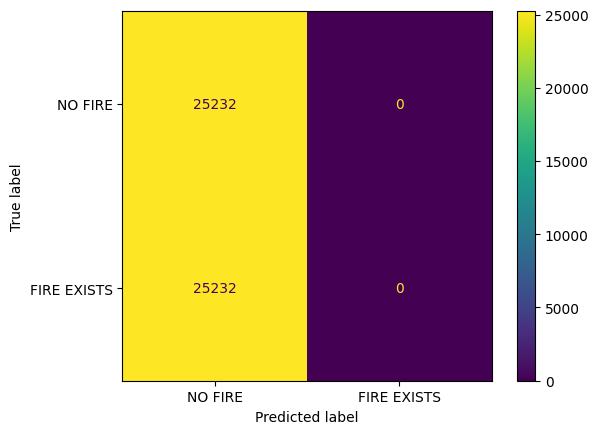

In [12]:
# Plot the confusion matrix.
cm_display = ConfusionMatrixDisplay.from_estimator(
    estimator = dummy_clf,
    X = X_train,
    y = y_train,
    display_labels = ["NO FIRE", "FIRE EXISTS"]
)

cm = cm_display.confusion_matrix

print(f"TN : {cm[0, 0]}")
print(f"FP : {cm[0, 1]}")
print(f"FN : {cm[1, 0]}")
print(f"TP : {cm[1, 1]}\n")

plt.show()

### **4.2. Model Fit & Tune**

In [13]:
# Function to fit & tune model (CV + HT).
def evaluate_model(models, hyperparameters, config, path_log):
    """Cross Validation & Hyperparameter Tuning."""

    # Load data train.
    X_train, y_train = load_data(config, "train")

    # Create training log.
    logger = create_training_log()

    # Define a dictionary to store the trained models.
    trained_models = {}

    # Fit & tune each model.
    for m, h in zip(models, hyperparameters):
        print()
        utils.print_debug(f"Fit & Tune Model : {m['model_name']}...")

        # Create tuner object.
        tuner = RandomizedSearchCV(
            estimator = m["model_object"],
            param_distributions = hyperparameters[h],
            n_iter = 100,
            scoring = "recall",
            cv = 5,
            return_train_score = True,
            n_jobs = -1,
            verbose = 1
        )

        # Compute the training time.
        start_time = utils.time_stamp()
        tuner.fit(X_train, y_train)
        finished_time = utils.time_stamp()

        training_time = finished_time - start_time
        training_time = training_time.total_seconds()

        # Get the model with best hyperparameters.
        best_model = tuner.best_estimator_

        # Get the scores of best model.
        best_index = tuner.best_index_
        train_score = tuner.cv_results_["mean_train_score"][best_index]
        cv_score = tuner.cv_results_["mean_test_score"][best_index]

        # Store the training information.
        logger["model_name"].append(m["model_name"])

        plain_id = str(training_time)
        cipher_id = hashlib.md5(plain_id.encode()).hexdigest()
        logger["model_id"].append(cipher_id)

        logger["training_time"].append(training_time)
        logger["training_date"].append(str(start_time))
        logger["train_score"].append(train_score)
        logger["cv_score"].append(cv_score)

        # Store the best model.
        trained_models[m["model_name"]] = [best_model, train_score, cv_score]

    # Update the current training log.
    training_log = update_training_log(logger, path_log)

    return trained_models, training_log

In [14]:
PATH_LOG = "logs/training_log.json"

# Create model objects and hyperparameter space.
models = create_model_object()
hyperparameters = create_param_space()

# Fit & tune models.
trained_models, training_log = evaluate_model(models, hyperparameters, config, PATH_LOG)

Data deserialized from data/processed/X_train_clean.pkl
Data deserialized from data/processed/y_train_clean.pkl

2026-03-07 03:07:52.166816 Fit & Tune Model : KNeighborsClassifier...
Fitting 5 folds for each of 28 candidates, totalling 140 fits

2026-03-07 03:09:12.149192 Fit & Tune Model : LogisticRegression...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

2026-03-07 03:09:13.269744 Fit & Tune Model : DecisionTreeClassifier...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

2026-03-07 03:09:16.285360 Fit & Tune Model : BaggingClassifier...
Fitting 5 folds for each of 9 candidates, totalling 45 fits

2026-03-07 03:15:18.569263 Fit & Tune Model : RandomForestClassifier...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

2026-03-07 03:30:03.714282 Fit & Tune Model : AdaBoostClassifier...
Fitting 5 folds for each of 45 candidates, totalling 225 fits

2026-03-07 03:40:59.900481 Fit & Tune Model : GradientBoostingClassifier...
Fitting 5 folds for e

In [15]:
# Update the configuration file.
config = utils.update_config(
    key = "path_training_log",
    value = PATH_LOG,
    config = config
)

Params Updated! 
Key: path_training_log 
Value: logs/training_log.json



In [16]:
# Function to show the performance summary.
def training_log_to_df(training_log):
    """Return dataframe of performance summary."""
    performances = pd.DataFrame()

    for log in training_log:
        performances = pd.concat([performances, pd.DataFrame(log)])

    performances = performances.sort_values(
        ["cv_score", "training_time"],
        ascending = [False, True]
    )

    performances = performances.reset_index(drop=True)

    selected_cols = ["model_name", "train_score", "cv_score", "training_time"]
    return performances[selected_cols]

In [17]:
performances = training_log_to_df(training_log)
performances

,model_name,train_score,cv_score,training_time
0,AdaBoostClassifier,1.000000,1.000000,656.185915
1,GradientBoostingClassifier,1.000000,1.000000,3899.839970
2,KNeighborsClassifier,1.000000,0.999960,79.981833
3,RandomForestClassifier,0.999980,0.999960,885.144717
4,BaggingClassifier,0.999960,0.999841,362.283553
5,LogisticRegression,0.999841,0.999802,1.120267
6,DecisionTreeClassifier,1.000000,0.999762,3.015341


### **4.3. Best Model Prediction**

Get the best model and check the performance on valid and test set.

In [33]:
best_name = performances["model_name"][0]
best_model = trained_models[best_name][0]
best_model

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",300
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


Best model recall on valid set : 0.9868185880250223
TN : 1043
FP : 744
FN : 59
TP : 4417



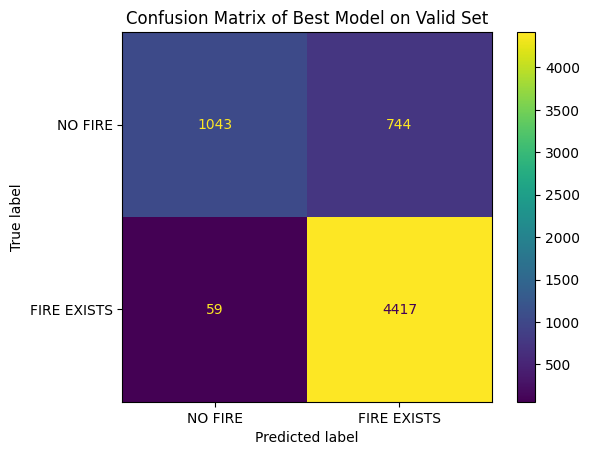

In [34]:
# Performance on valid set.
y_valid_pred = best_model.predict(X_valid)
valid_score = recall_score(
    y_true = y_valid,
    y_pred = y_valid_pred
)

print(f"Best model recall on valid set : {valid_score}")

# Plot the confusion matrix.
cm_display = ConfusionMatrixDisplay.from_estimator(
    estimator = best_model,
    X = X_valid,
    y = y_valid,
    display_labels = ["NO FIRE", "FIRE EXISTS"]
)

cm = cm_display.confusion_matrix

print(f"TN : {cm[0, 0]}")
print(f"FP : {cm[0, 1]}")
print(f"FN : {cm[1, 0]}")
print(f"TP : {cm[1, 1]}\n")

plt.title("Confusion Matrix of Best Model on Valid Set")
plt.show()

Best model recall on test set : 0.822609472743521
TN : 301
FP : 1486
FN : 794
TP : 3682



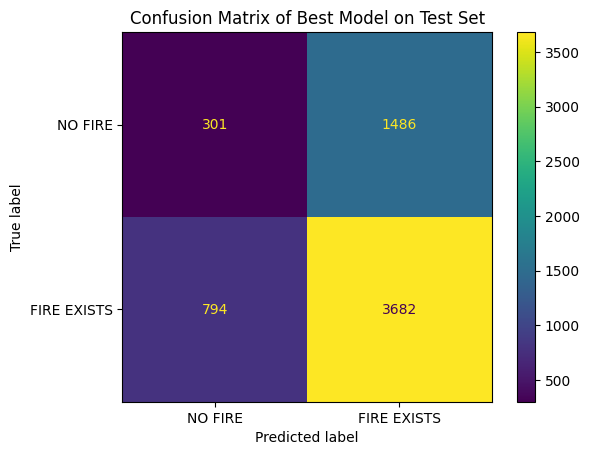

In [35]:
# Performance on test set.
y_test_pred = best_model.predict(X_test)
test_score = recall_score(
    y_true = y_test,
    y_pred = y_test_pred
)

print(f"Best model recall on test set : {test_score}")

# Plot the confusion matrix.
cm_display = ConfusionMatrixDisplay.from_estimator(
    estimator = best_model,
    X = X_test,
    y = y_test,
    display_labels = ["NO FIRE", "FIRE EXISTS"]
)

cm = cm_display.confusion_matrix

print(f"TN : {cm[0, 0]}")
print(f"FP : {cm[0, 1]}")
print(f"FN : {cm[1, 0]}")
print(f"TP : {cm[1, 1]}\n")

plt.title("Confusion Matrix of Best Model on Test Set")
plt.show()

## **5 - Model Serialization**
---

In [21]:
# Serialize the best model.
PATH_PRODUCTION_MODEL = "models/best_model.pkl"
utils.serialize_data(best_model, PATH_PRODUCTION_MODEL)

Data serialized to models/best_model.pkl


['models/best_model.pkl']

In [22]:
# Update the configuration file.
config = utils.update_config(
    key = "path_production_model",
    value = PATH_PRODUCTION_MODEL,
    config = config
)

Params Updated! 
Key: path_production_model 
Value: models/best_model.pkl



In [23]:
# Check the configuration file.
config

{'columns_datetime': ['utc'],
 'columns_float': ['temperature',
  'humidity_pct',
  'pressure',
  'pm10',
  'pm25',
  'nc05',
  'nc10',
  'nc25'],
 'columns_int': ['tvoc', 'co2', 'raw_h2', 'raw_ethanol', 'fire_alarm'],
 'features': ['temperature',
  'humidity_pct',
  'pressure',
  'pm10',
  'tvoc',
  'co2',
  'raw_h2',
  'raw_ethanol'],
 'label': 'fire_alarm',
 'path_clean_test': ['data/processed/X_test_clean.pkl',
  'data/processed/y_test_clean.pkl'],
 'path_clean_train': ['data/processed/X_train_clean.pkl',
  'data/processed/y_train_clean.pkl'],
 'path_clean_valid': ['data/processed/X_valid_clean.pkl',
  'data/processed/y_valid_clean.pkl'],
 'path_data_raw': 'data/raw/smoke_detection_iot.csv',
 'path_data_test': ['data/interim/X_test.pkl', 'data/interim/y_test.pkl'],
 'path_data_train': ['data/interim/X_train.pkl', 'data/interim/y_train.pkl'],
 'path_data_valid': ['data/interim/X_valid.pkl', 'data/interim/y_valid.pkl'],
 'path_data_validated': 'data/interim/validated_data.pkl',
 'pat